In [2]:
import sys
sys.path.append('../')

In [3]:
import Hamiltonian as ham
import scipy.sparse as sp
import numpy as np
from matplotlib import pyplot as plt
import Evolution as evol

In [4]:
def fidelity_pure(psi,phi):
    '''
    input values should be column vectors
    '''
    F=np.abs(psi.conj().T@phi)**2
    return F[0,0]

def variance(psi,H):
    V=np.real((psi.conj().T@H@H@psi)-(psi.conj().T@H@psi)**2)
    return V[0,0]


In [5]:
from qrisp.operators import X, Y, Z

def TFIM_qr(J,h,n_qubits):
    H = 0
    for i in range(n_qubits):
        i_next = (i+1)%n_qubits
        H += J*Z(i)*Z(i_next) + h*X(i)
    return H

/home/luca/Documents/QITE-UV/Qite/lib/python3.12/site-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.1 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


In [ ]:
n_qubits=5
J=0.5
h=1.0
H = TFIM_qr(J,h,n_qubits)

print('Computing Eigs')
EH,VH = np.linalg.eigh(H.to_array())
psigs=VH[:,0:1]
E_gs=EH[0]

def exp_H(qv,t):
    # Applies 5 Trotter steps of the Hamiltonian evolution
    H.trotterization(method='commuting')(qv, t, 1)

def U_0(qv):
    pass

In [40]:
from run_qite import run_QITE

s_values = np.linspace(0.01, 1.5, 20)
steps = 8
results = run_QITE(H, U_0, exp_H, s_values, steps,use_statevectors=True)

Step 1/8...                                                                     
Step 2/8...                                                                     
Step 3/8...                                                                     
Step 4/8...                                                                     
Step 5/8...                                                                     
Step 6/8...                                                                     
Step 7/8...                                                                     
Step 8/8...                                                                     


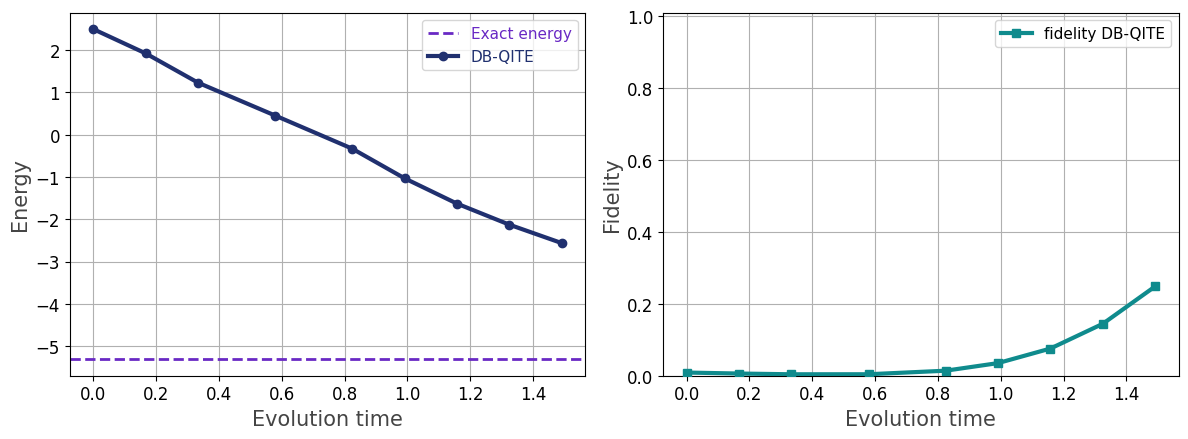

In [41]:
import matplotlib.pyplot as plt
import numpy as np

fidelities = [fidelity_pure(psigs, results['statevectors'][k].reshape(-1,1)) for k in range(steps+1)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Energy plot
ax1.set_xlabel('Evolution time', fontsize=15, color='#444444')
ax1.set_ylabel('Energy', fontsize=15, color='#444444')
ax1.axhline(y=E_gs, color='#6929C4', linestyle='--', linewidth=2, label='Exact energy')
ax1.plot(results['evolution_times'], results['optimal_energies'], c='#20306f', marker='o', linestyle='solid', linewidth=3, zorder=3, label='DB-QITE')
ax1.legend(fontsize=11, labelcolor='linecolor')
ax1.tick_params(axis='both', labelsize=12)
ax1.grid()

# Fidelity plot
ax2.set_xlabel('Evolution time', fontsize=15, color='#444444')
ax2.set_ylabel('Fidelity', fontsize=15, color='#444444')
ax2.plot(results['evolution_times'], fidelities, c='#0f8b8d', marker='s', linestyle='solid', linewidth=3, zorder=3, label='fidelity DB-QITE')
ax2.set_ylim(0.0, 1.01)
ax2.legend(fontsize=11)
ax2.tick_params(axis='both', labelsize=12)
ax2.grid()

plt.savefig(f'TFIM_N{n_qubits}_J{J}_h{h}_steps{steps}_DBF_results.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [42]:
results['circuit_data']

[{0: {},
  1: {'u3': 73, 'cz': 50},
  2: {'u3': 257, 'cz': 180},
  3: {'u3': 828, 'cz': 586},
  4: {'u3': 2518, 'cz': 1784},
  5: {'u3': 7602, 'cz': 5398},
  6: {'u3': 22840, 'cz': 16220},
  7: {'u3': 68522, 'cz': 48666},
  8: {'u3': 205539, 'cz': 145984}},
 {0: 5, 1: 7, 2: 7, 3: 7, 4: 7, 5: 7, 6: 7, 7: 7, 8: 7},
 {0: 0,
  1: 69,
  2: 258,
  3: 840,
  4: 2565,
  5: 7761,
  6: 23328,
  7: 70012,
  8: 210043}]

In [43]:
import Hamiltonian as ham
import Evolution as evol

H_acq,H_trot=ham.TFIM(J,h,n_qubits,T=2)

#initial state
psi0np=np.zeros((2**n_qubits,1),dtype=complex)
psi0np[0]=1
psi_0=sp.csc_matrix(psi0np/np.linalg.norm(psi0np))

#QITE and ACQ evolution
D=2
dt = 0.1
N = 100
print("Computing ACQ")
E_ACQ,psi_ACQ,indx_acq,times_acq,a_acq = evol.ACQ(n_qubits,H_acq,H_trot,D,psi_0,N,dt,methodLS='LU')

Computing ACQ
Using Real Pauli Strings
Computing U at step 0
Computing U at step 8
Computing U at step 10
Energy doubly increased, stopping criteria activated at step 11


In [44]:
import PauliStrings as ps
from run_qite import build_acq_circuit_qrisp

num_paulis,PD,fail = ps.real(H_trot,D,n_qubits,PDstr=True)
circuit_ops = {}
circuits = {}
steps_acq = len(a_acq)

for step in range(steps_acq+1): 
    qc = build_acq_circuit_qrisp(n_qubits,D,2,PD,a_acq,times_acq,step,U_0)
    tqc = qc.transpile(basis_gates=['cz','u'])

    circuits[step] = qc
    circuit_ops[step] = tqc.count_ops()

circuit_data = {
    'circuits': circuits,
    'circuit_ops': circuit_ops
}


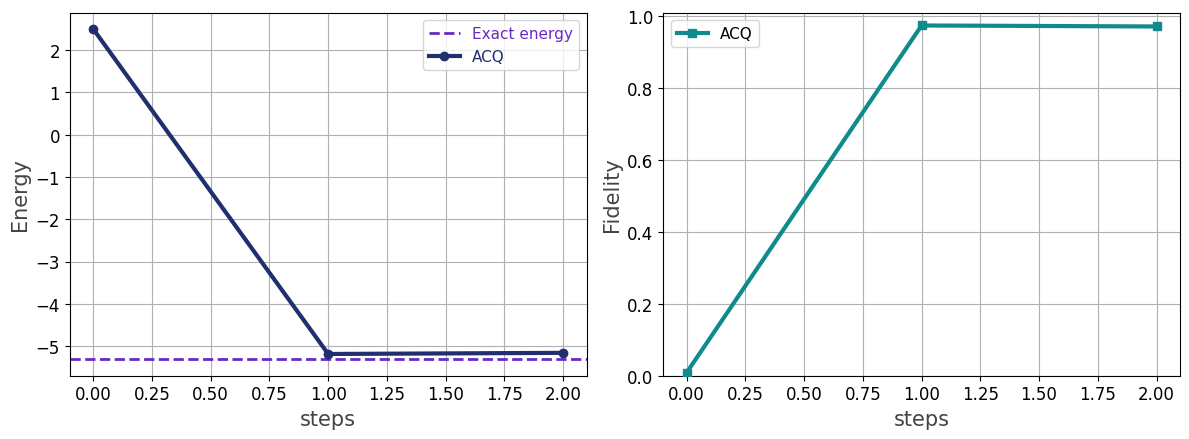

In [46]:
from run_qite import get_statevector,compute_moments

energies_acq = [compute_moments(get_statevector(circuits[step],n_qubits),H_acq)[0] for step in range(steps_acq+1)]
fidelities_acq = [fidelity_pure(psigs, get_statevector(circuits[step],n_qubits).reshape(-1,1)) for step in range(steps_acq+1)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
# Energy plot
ax1.set_xlabel('steps', fontsize=15, color='#444444')
ax1.set_ylabel('Energy', fontsize=15, color='#444444')
ax1.axhline(y=E_gs, color='#6929C4', linestyle='--', linewidth=2, label='Exact energy')
ax1.plot(range(steps_acq+1), energies_acq, c='#20306f', marker='o', linestyle='solid', linewidth=3, zorder=3, label='ACQ')
ax1.legend(fontsize=11, labelcolor='linecolor')
ax1.tick_params(axis='both', labelsize=12)
ax1.grid()

# Fidelity plot
ax2.set_xlabel('steps', fontsize=15, color='#444444')
ax2.set_ylabel('Fidelity', fontsize=15, color='#444444')
ax2.plot(range(steps_acq+1), fidelities_acq, c='#0f8b8d', marker='s', linestyle='solid', linewidth=3, zorder=3, label='ACQ')
ax2.set_ylim(0.0, 1.01)
ax2.legend(fontsize=11, loc='upper right')
ax2.set_ylim(0.0, 1.01)
ax2.legend(fontsize=11)
ax2.tick_params(axis='both', labelsize=12)
ax2.grid()

plt.savefig(f'TFIM_N{n_qubits}_J{J}_h{h}_steps{steps_acq}_ACQ_results.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [38]:
circuit_data['circuit_ops']

{0: {}, 1: {'u3': 25, 'cz': 10}, 2: {'u3': 45, 'cz': 20}}